In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from utilsforecast.preprocessing import fill_gaps
from tinyshift.stats import remove_leading_zeros, is_obsolete
from tinyshift.plot import stationarity_analysis, pami, residual_analysis, seasonal_decompose
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import MSTL
from statsforecast.models import SeasonalNaive, AutoETS
#from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, bias, cfe 
from tinyshift.series.stability import *
from tinyshift.series.interpolation import *
from tinyshift.series import wape, fva_rmae, pbias, score, forecast_instability, rmae, extract_mstl_components, detect_seasonal_periods
from tinyshift.forecasting import DMSTLWrapper
from tinyshift.features import fourier_seasonality
from mlforecast.utils import PredictionIntervals

/home/heylucasleao/tinyshift/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df["unique_id"] = "1"
df.rename(columns={"Month": "ds", "Passengers": "y"}, inplace=True)
df = fill_gaps(df, freq="ME", end="per_serie", id_col="unique_id", time_col="ds")
df = df.groupby("unique_id")[df.columns].apply(remove_leading_zeros).reset_index(drop=True)
df = fourier_seasonality(df, "ds", seasonality=["monthly"])
days_obsoletes=180
obsolete_series = df.groupby("unique_id")[df.columns].apply(is_obsolete, days_obsoletes)
obsolote_ids = obsolete_series[obsolete_series].index.tolist()
assert len(obsolote_ids) == 0, f"Obsolete series found: {obsolote_ids}"

In [3]:
metrics = [rmse, mae, bias, wape, pbias, score, forecast_instability]

In [4]:
df.isnull().sum()

unique_id      0
ds             0
y              0
monthly_sin    0
monthly_cos    0
dtype: int64

## MSTL + ML

In [5]:
horizon = 12
train = df[:-horizon]
test = df[-horizon:]

In [6]:
periods = detect_seasonal_periods(df["y"], top_k=2, noise_threshold_factor=2.0)

In [7]:
periods

[6, 12]

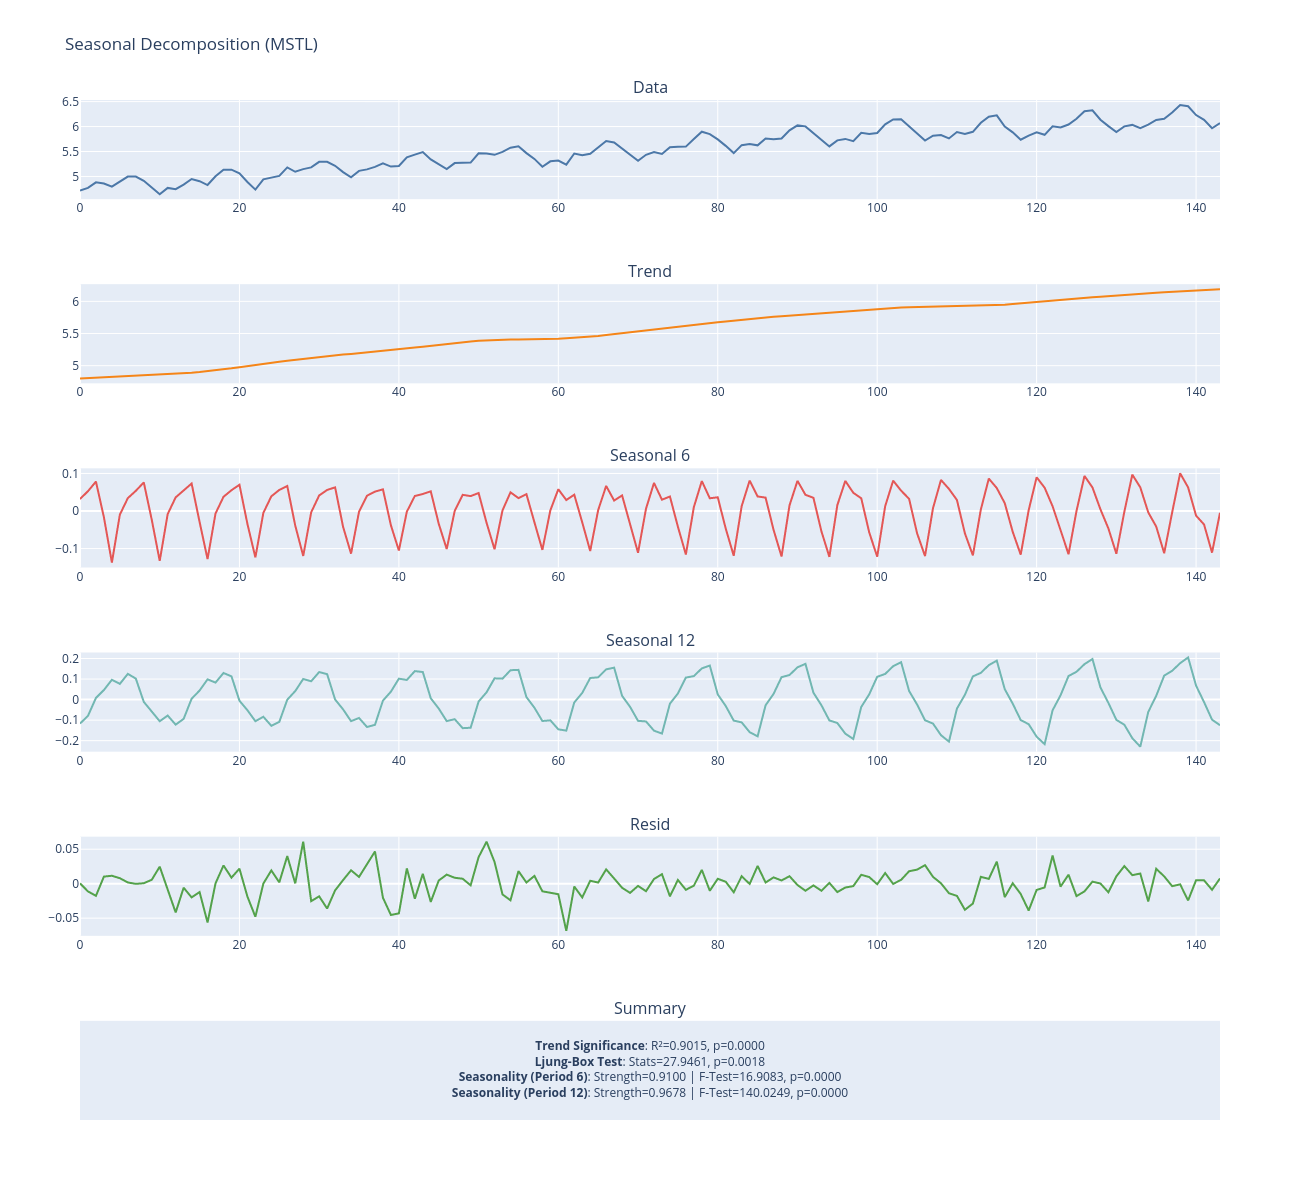

In [8]:
seasonal_decompose(np.log(df["y"]),periods=periods,fig_type="png")

In [9]:
#def compute_lgbm_params(N: int):
#    max_depth = int(np.ceil(np.log2(N) - 1))
#    subsample_freq = 1
#    colsample_bytree = 0.7
#    n_estimators = 1000
#    reg_lambda = 0.2
#    reg_alpha = 0.2
#    metric = "mae"
#    learning_rate = 0.05
#    min_child_samples = max(20, int(np.cbrt(N)))
#    n_jobs = -1
#    random_state = 42
#
#    return {
#        "max_depth": int(max_depth),
#        "subsample_freq": subsample_freq,
#        "colsample_bytree": colsample_bytree,
#        "n_estimators": n_estimators,
#        "metric": metric,
#        "learning_rate": learning_rate,
#        "num_leaves": 40,
#        "min_child_samples": min_child_samples,
#        "reg_alpha": reg_alpha,
#        "reg_lambda": reg_lambda,
#        "objective": "regression_l2",
#        "n_jobs": n_jobs,
#        "random_state": random_state
#    }
#models = [LGBMRegressor(n_estimators=1000, random_state=42), RandomForestRegressor(n_estimators=100, random_state=42)]
#config = compute_lgbm_params(len(train))
models = [LinearRegression(), RandomForestRegressor(n_estimators=100, random_state=42)]

In [10]:
mstl = MSTL(train["y"], periods=periods).fit()
decomp = extract_mstl_components(mstl, periods)

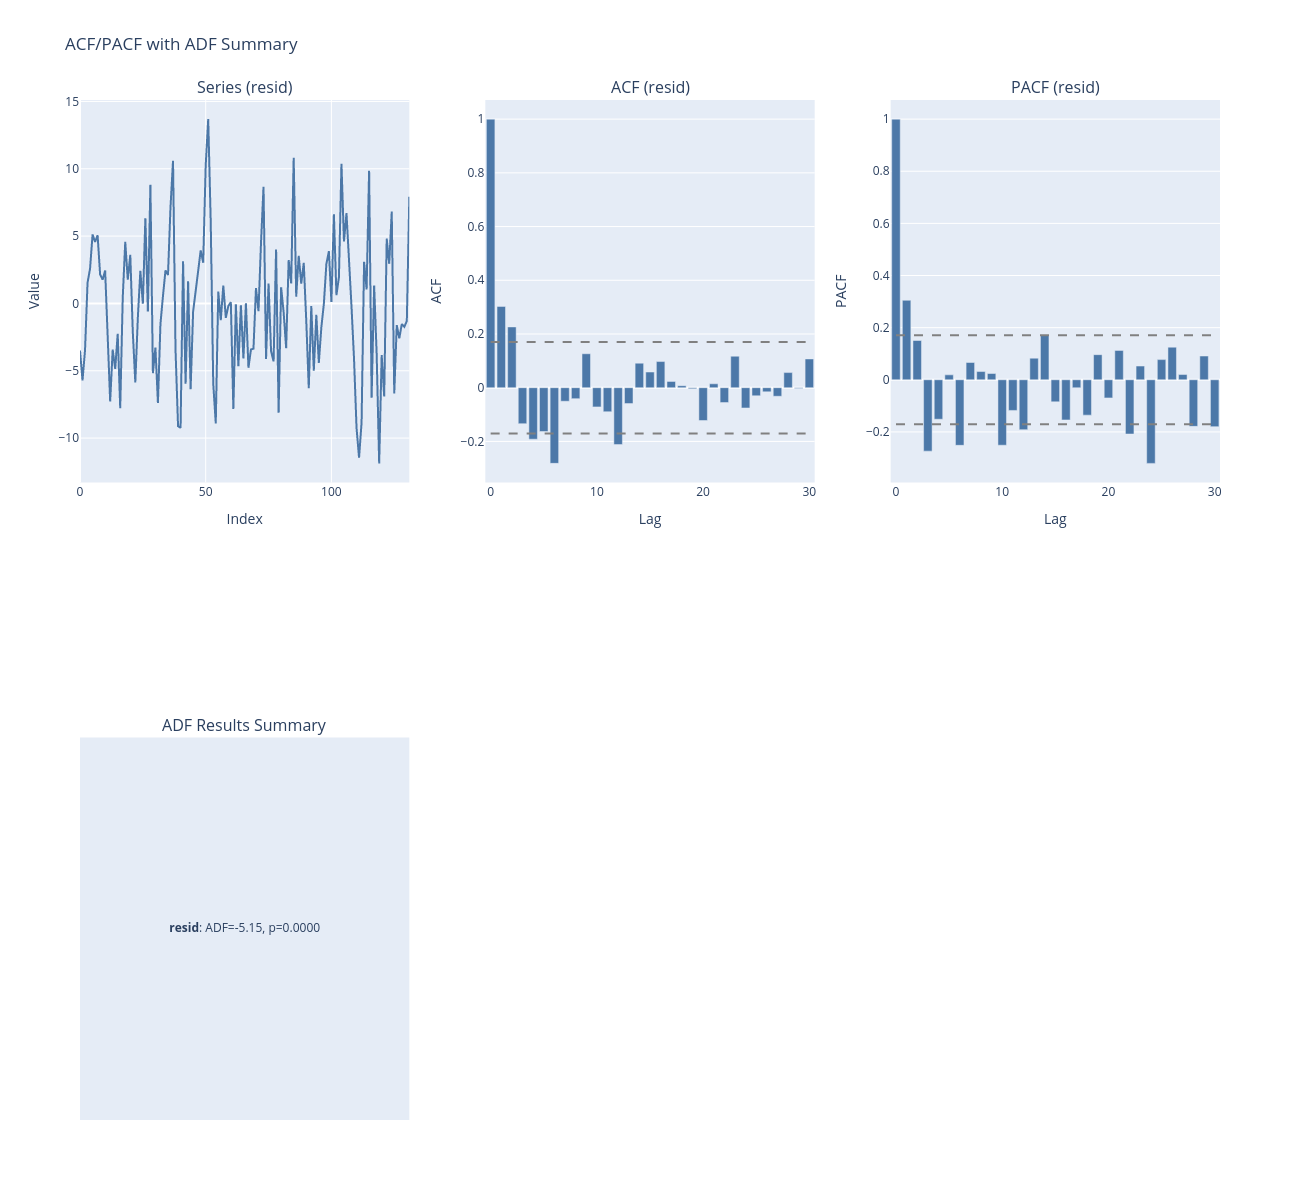

In [11]:
stationarity_analysis(decomp["resid"], nlags=30, fig_type="png")

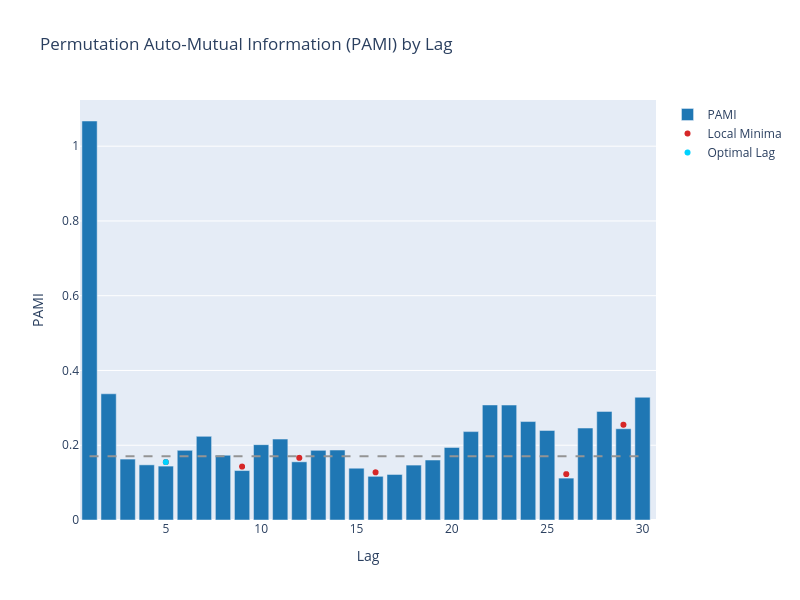

In [12]:
pami(decomp["resid"], nlags=30, fig_type="png", m=3, normalize=False)

In [13]:
def seasonal_callable(period):
    return AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    )


def trend_model_callable():
    return AutoETS(
        model="ZAN",
        alias="Trend-AutoETS",
    )


def residual_model_callable(nlags, freq):
    return MLForecast(
        models=models,
        lags=nlags,
        freq=freq,
    )


dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length=periods,
    trend_model_callable=trend_model_callable,
    seasonal_model_callable=seasonal_callable,
    nlags=[1, 5],
)

In [14]:
dmstl.fit(train[["unique_id", "ds", "y"]], target_col="y")

,mode,'global'
,residual_model_callable,<function res...x7c2375dba160>
,freq,'MS'
,season_length,"[6, 12]"
,seasonal_detection_params,None
,trend_model_callable,<function tre...x7c2375dba520>
,seasonal_model_callable,<function sea...x7c2375db8ea0>
,nlags,"[1, 5]"
,pami_params,None
,log_transform,False


In [15]:
result = dmstl.predict(h=12)
result["y"] = test["y"].values

In [16]:
evaluate(result, 
         metrics=metrics, 
         models=["LinearRegression", "RandomForestRegressor"], 
         id_col="unique_id", 
         time_col="ds", 
         target_col="y")

,unique_id,metric,LinearRegression,RandomForestRegressor
0,1,rmse,18.853033,20.442186
1,1,mae,15.326620,15.884758
2,1,bias,10.275310,11.591380
3,1,wape,3.218751,3.335966
4,1,pbias,2.157923,2.434311
5,1,score,5.376674,5.770277
6,1,forecast_instability,9.269926,9.150201


In [17]:
result["residual_dmstl_lr"] = result["y"].values - result["LinearRegression"].values
result["residual_dmstl_rf"] = result["y"].values - result["RandomForestRegressor"].values

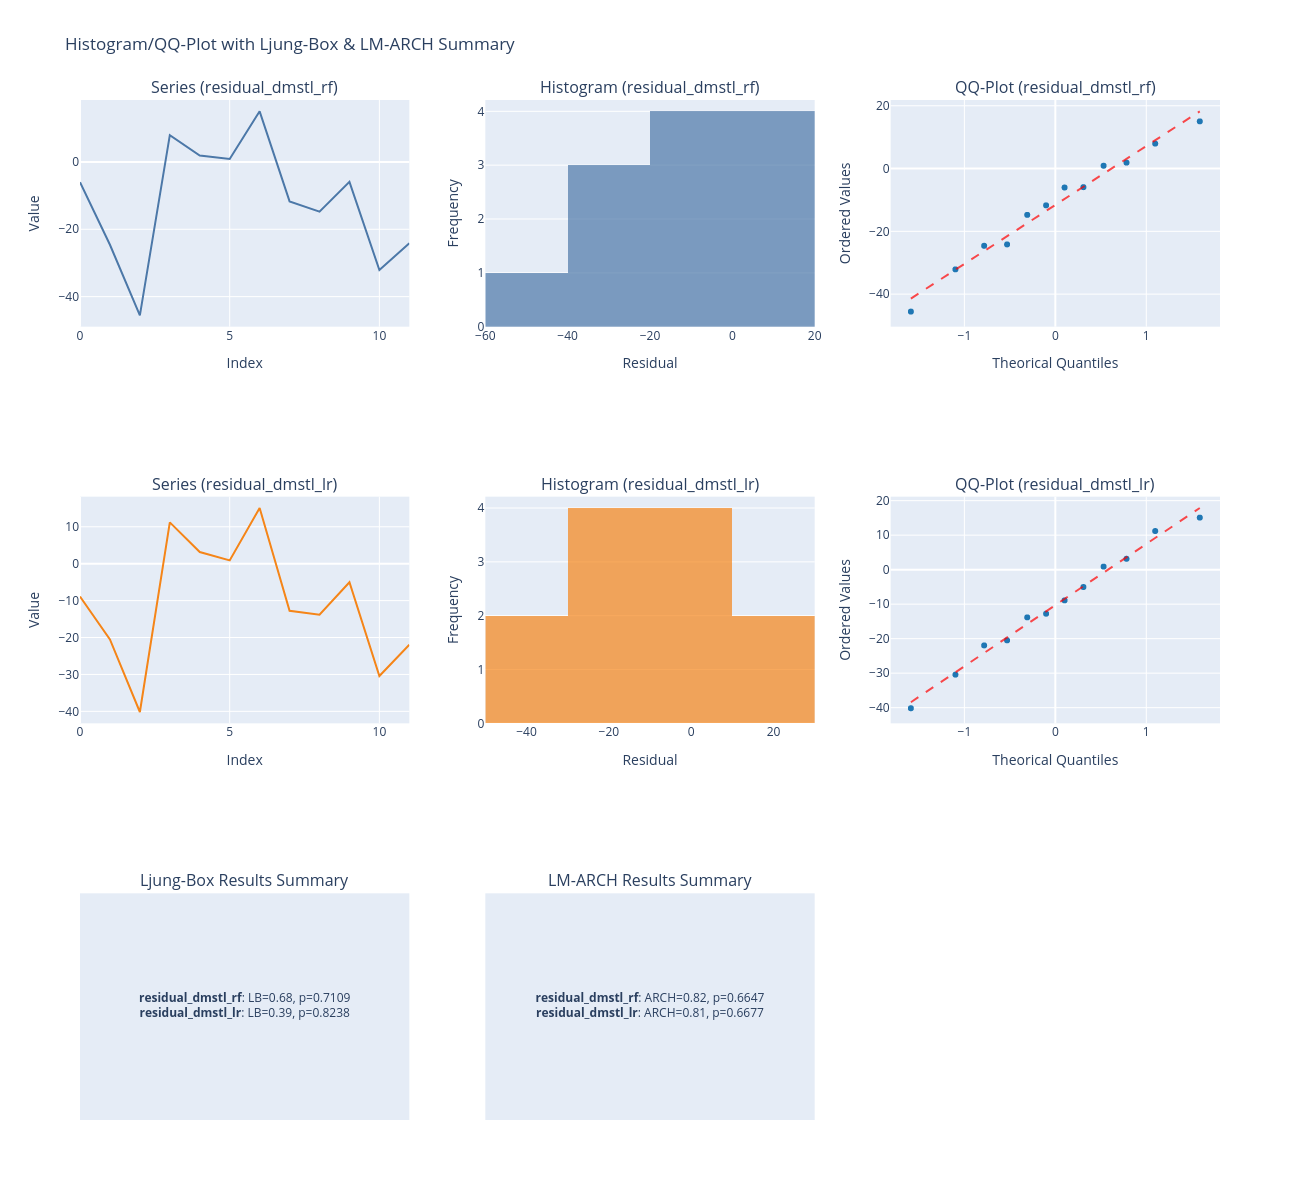

In [18]:
residual_analysis(result[["residual_dmstl_rf", "residual_dmstl_lr"]], nlags=30, fig_type="png")

## Horizontal Partial Interpolation

In [19]:
result["y_pred_pi"] = dmstl.predict(h=12, stabilization_method="hpi", w_s=0.8)["RandomForestRegressor"]
mac_h_result = mach(result["y_pred_pi"])
print(f"MAC(H) (Horizontal Stability): {mac_h_result:.6f}")

MAC(H) (Horizontal Stability): 34.621336


## Horizontal Full Interpolation

In [20]:
result["y_pred_fi"] = dmstl.predict(h=12, stabilization_method="hfi", w_s=0.8)["RandomForestRegressor"]
mac_h_result = mach(result["y_pred_fi"])
print(f"MAC(H) (Horizontal Stability): {mac_h_result:.6f}")

MAC(H) (Horizontal Stability): 11.845382


In [21]:
fva_rmae(result["y"].values, result["RandomForestRegressor"].values, nlags=1, baseline_type="naive")

0.34760171166111026

In [22]:
fva_rmae(result["y"].values, result["RandomForestRegressor"].values, baseline_type="moving_average", window_size=3)

0.24233239679481344

# Prediction Intervals

In [23]:
periods

[6, 12]

In [24]:
def callable_autoets(period):
    return AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    )


prediction_intervals = PredictionIntervals(
    n_windows=3,
    h=14,
)
dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length=periods,
    seasonal_model_callable=callable_autoets,
    nlags=[1, 5],
)
dmstl.fit(
    train[["unique_id", "ds", "y"]],
    target_col="y",
    prediction_intervals=prediction_intervals,
)
forecasts = dmstl.predict(
    h=14,
    level=[95],
)

In [25]:
dmstl.fit(
    train[["unique_id", "ds", "y"]],
    target_col="y",
    prediction_intervals=prediction_intervals,
)
forecasts = dmstl.predict(
    h=14,
    level=[95],
)

In [26]:
evaluate(result,
         metrics=metrics,
         models=["RandomForestRegressor"],
         id_col="unique_id",
         time_col="ds",
         target_col="y")

,unique_id,metric,RandomForestRegressor
0,1,rmse,20.442186
1,1,mae,15.884758
2,1,bias,11.591380
3,1,wape,3.335966
4,1,pbias,2.434311
5,1,score,5.770277
6,1,forecast_instability,9.150201


## Per-SKU Seasonal Periods with DMSTLWrapper

`DMSTLWrapper` accepts a dictionary when different series require different seasonal periods. Each key must match a `unique_id`, and each value can be a single period or a list of periods.

The first configuration below is explicit. The second one uses `detect_seasonal_periods` on the complete panel and passes its per-SKU result directly to `DMSTLWrapper`.


In [27]:
panel = pd.concat(
    [
        train.assign(unique_id="sku-a"),
        train.assign(unique_id="sku-b"),
    ],
    ignore_index=True,
)

manual_season_lengths = {
    "sku-a": [7, 30],
    "sku-b": 12,
}
trend_model_callable = {
    "sku-a": lambda: AutoETS(model="ZZN", alias="Trend-sku-a"),
    "sku-b": lambda: AutoETS(model="ZNN", alias="Trend-sku-b"),
}
manual_dmstl = DMSTLWrapper(
    mode="local",
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length=manual_season_lengths,
    trend_model_callable=trend_model_callable,
    nlags={"sku-a": [1, 2, 3], "sku-b": "auto"},
    pami_params={"max_tau": 24, "m": 3, "delay": 1, "return_mode": "value_only"},
)
manual_dmstl.fit(panel[["unique_id", "ds", "y"]], target_col="y")

manual_season_lengths

{'sku-a': [7, 30], 'sku-b': 12}

In [28]:
manual_dmstl.fitted_models_

{'sku-a': {'trend': StatsForecast(models=[Trend-sku-a]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-7]),
   StatsForecast(models=[SeasonalNaive-30])],
  'residual': MLForecast(models=[LinearRegression, RandomForestRegressor], freq=MS, lag_features=['lag1', 'lag2', 'lag3'], date_features=[], num_threads=1)},
 'sku-b': {'trend': StatsForecast(models=[Trend-sku-b]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-12])],
  'residual': MLForecast(models=[LinearRegression, RandomForestRegressor], freq=MS, lag_features=['lag3'], date_features=[], num_threads=1)}}

In [29]:
detected_season_lengths = detect_seasonal_periods(
    panel,
    top_k=2,
    target_col="y",
)

In [30]:
seasonal_model_callable = {
    "sku-a": lambda period: AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    ),
    "sku-b": lambda period: SeasonalNaive(
        season_length=period,
        alias=f"SeasonalNaive-{period}",
    ),
}
detected_dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length="auto",
    seasonal_detection_params={
        "top_k": 2,
    },
    seasonal_model_callable=seasonal_model_callable,
    nlags="auto",
    #pami_params={"max_tau": 365, "m": 3, "delay": 1, "return_mode": "short_term", "short_term": 1},
    pami_params={"return_mode": "range"}
)
detected_dmstl.fit(
    panel[["unique_id", "ds", "y"]],
    target_col="y",
    prediction_intervals=prediction_intervals,
)

detected_season_lengths

{'sku-a': [6, 12], 'sku-b': [6, 12]}

In [31]:
detected_dmstl.fitted_models_

{'sku-a': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[AutoETS-6]),
   StatsForecast(models=[AutoETS-12])]},
 'sku-b': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-6]),
   StatsForecast(models=[SeasonalNaive-12])]}}

In [32]:
result = detected_dmstl.predict(h=12)

In [33]:
result = detected_dmstl.predict(h=12)
result = result[result["unique_id"] == "sku-a"]
result["y"] = test["y"].values
evaluate(result,
         metrics=metrics,
         models=["RandomForestRegressor"],
         id_col="unique_id",
         time_col="ds",
         target_col="y")

,unique_id,metric,RandomForestRegressor
0,sku-a,rmse,19.747635
1,sku-a,mae,15.591610
2,sku-a,bias,12.895812
3,sku-a,wape,3.274402
4,sku-a,pbias,2.708256
5,sku-a,score,5.982658
6,sku-a,forecast_instability,9.083861


## DMSTL com variavel exogena dinamica

`promotion` esta disponivel no treino e no horizonte futuro. `static_features=[]` informa ao MLForecast que ela e uma variavel dinamica, e `X_df` fornece seus valores futuros.

In [34]:
exog_train = train[["unique_id", "ds", "y"]].copy()
exog_train["promotion"] = exog_train["ds"].dt.month.isin([3, 9]).astype(float)


def residual_model_with_exog(nlags, freq):
    return MLForecast(
        models=[LinearRegression()],
        lags=nlags,
        freq=freq,
    )


exog_dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_with_exog,
    freq="MS",
    season_length=periods,
    trend_model_callable=trend_model_callable,
    seasonal_model_callable=seasonal_callable,
    nlags=[1, 5],
)

exog_dmstl.fit(
    exog_train,
    target_col="y",
    static_features=[],
)
exog_dmstl.exog_cols_

['promotion']

In [35]:
exog_future = test[["unique_id", "ds"]].copy()
exog_future["promotion"] = exog_future["ds"].dt.month.isin([3, 9]).astype(float)

exog_forecasts = exog_dmstl.predict(
    h=horizon,
    X_df=exog_future,
)

exog_forecasts

,unique_id,ds,LinearRegression
0,1,1960-01-01,425.897582
1,1,1960-02-01,411.492883
2,1,1960-03-01,459.200933
3,1,1960-04-01,449.806007
4,1,1960-05-01,468.841286
5,1,1960-06-01,534.114958
6,1,1960-07-01,606.911241
7,1,1960-08-01,618.754040
8,1,1960-09-01,521.862138
9,1,1960-10-01,466.037419


## Saving and Loading a DMSTL Model

`DMSTLWrapper` is a plain scikit-learn compatible estimator, so it can be persisted with `joblib`, which is already a `tinyshift` dependency. This preserves every fitted StatsForecast and MLForecast model held internally, for both `mode="local"` and `mode="global"`.

In [29]:
import joblib

model_path = "dmstl_model.joblib"

# Save the fitted wrapper (works the same for mode="local" or mode="global").
joblib.dump(dmstl, model_path)

# Load it back into a new object.
loaded_dmstl = joblib.load(model_path)

loaded_forecast = loaded_dmstl.predict(h=12)
loaded_forecast.head()

,unique_id,ds,LinearRegression,RandomForestRegressor
0,1,1960-01-01,425.904497,423.040588
1,1,1960-02-01,411.501287,415.599371
2,1,1960-03-01,459.171643,464.551089
3,1,1960-04-01,449.804051,453.055525
4,1,1960-05-01,468.847335,470.106878
